# 拡散モデル



VAEの章では、データを再構成するよう学習したEncoder・Decoderを用いて、新しいデータを生成する方法を説明した。
VAEを拡張して、潜在空間を多層化することもできるが、工夫をしないと、それぞれのEncoder/Decoderを各ステップで独立に作成することになり、学習が困難あるいは非現実的になってしまう。


**拡散モデル(Diffusion Model)** は、潜在空間にノイズを加える過程に対して、ノイズを除去する過程を学習することで、新しいデータを生成する手法である。

与えられたデータに対して、徐々にノイズを加えていき、最終的に完全なノイズに変換する過程を **拡散過程** と呼ぶ。逆に、ノイズから元のデータを復元する過程を **生成過程** あるいは **逆拡散過程** と呼ぶことにしよう。


拡散モデルの定式化は、以下で示すような、離散時間ステップに対する尤度の最大化問題として表現されるものに加えて、連続時間に対する微分方程式 (とくに確率微分方程式) を用いて表現されるものもある。この章では、離散時間ステップに対する定式化を中心に説明する。

参考になる文献は下記の通り(前者が、この章で説明する方法である):

- J. Ho et al.: "Denoising Diffusion Probabilistic Models", [arXiv:2006.11239 (NeurIPS 2020)](https://arxiv.org/abs/2006.11239).
- Y. Song et al.: "Score-Based Generative Modeling through Stochastic Differential Equations", [arXiv:2011.13456 (ICLR 2021)](https://arxiv.org/abs/2011.13456).

他の章とも同様、未知の確率分布を$p$、モデルの確率分布を$q$と表すことにする。


## 拡散過程

拡散過程は、セットアップさえ決めてしまえば、学習は必要のないステップになる。
画像データなどのベクトルデータに対して、ノイズを加える過程は、以下のように定式化される。

$$
\begin{align}
z_t = \sqrt{1 - \beta_t} z_{t-1} + \sqrt{\beta_t} \epsilon
\end{align}
$$

:::{margin}
ノイズを加えるだけなら$\sqrt{1 - \beta_t}$をかける必要はないのでは？と思うかもしれないが、このスケーリングがないとデータの分散が大きくなってしまう。
:::
ここで、$z_0 \equiv x$は元のデータを表すベクトル、$z_t$は$t$ステップ目のノイズが加えられたデータを表すベクトル、$\beta_t$は$t$ステップ目のノイズの強さを表すスカラー値、$\epsilon$は平均0、分散1のガウスノイズを表すベクトルである。

:::{margin}
VAEの章で変数変換トリックを導入したときと反対の形である。
:::
上のノイズを加える過程は、条件付き確率分布として表現することも出来る。

$$
\begin{align}
q(z_t| z_{t-1}) = \mathcal{N}(z_t| \sqrt{1 - \beta_t} z_{t-1}, \beta_t I)
\end{align}
$$

画像データに対してこの過程を適用すると、徐々に画像がぼやけていき、最終的には完全なノイズに変換される様子が観察される。
$\beta_t$は$t$に対して線形に大きくするような設定にして、実際にコードで試してみよう。


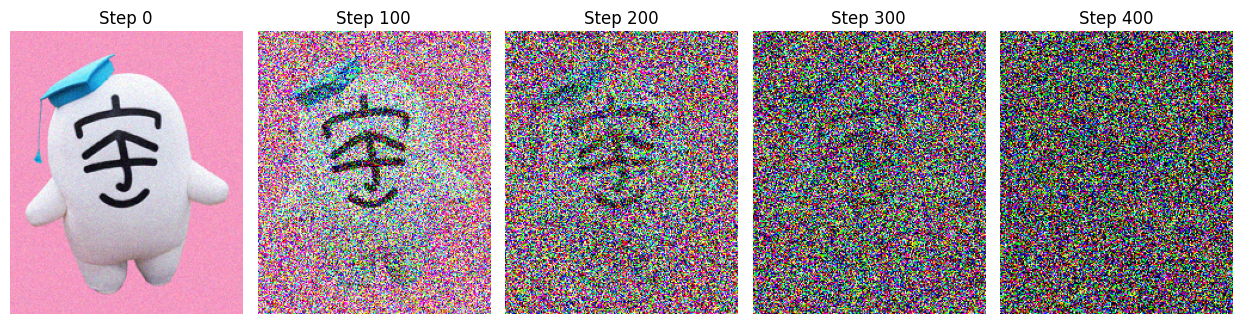

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

def load_image(url):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert('RGB')
    size =(int(img.width*0.3), int(img.height*0.3))
    img = img.resize(size)
    return np.array(img) / 255.0 

def forward_diffusion(x_0, timesteps, beta_start=0.001, beta_end=0.02):
    """
    画像を段階的にノイズ化する
    """
    # 線形のノイズスケジュール（beta）を作成
    betas = np.linspace(beta_start, beta_end, timesteps)
    alphas = 1.0 - betas
    alphas_cumprod = np.cumprod(alphas)  # 累積積（アルファバー）
    
    noisy_images = []
    
    # 特定のステップの画像を抽出してリストに保存
    display_steps = np.linspace(0, timesteps, 6, dtype=int)
    
    for t in range(timesteps):
        # ガウスノイズを生成
        noise = np.random.normal(size=x_0.shape)
        
        # 式: x_t = sqrt(alpha_bar) * x_0 + sqrt(1 - alpha_bar) * noise
        sqrt_alpha_cumprod = np.sqrt(alphas_cumprod[t])
        sqrt_one_minus_alpha_cumprod = np.sqrt(1.0 - alphas_cumprod[t])
        
        x_t = sqrt_alpha_cumprod * x_0 + sqrt_one_minus_alpha_cumprod * noise
        x_t = np.clip(x_t, 0, 1)  # 値を0-1の範囲に収める
        
        if t in display_steps:
            noisy_images.append((t, x_t))
            
    return noisy_images

# 1. 画像の読み込み（サンプルとしてネット上の画像を使用）
url = "https://raw.githubusercontent.com/SotaYoshida/Lecture_DataScience/main/notebooks/pic_for_notebook/u_ta.jpeg"
image = load_image(url)

# 2. 拡散プロセスの実行
steps = 500
results = forward_diffusion(image, timesteps=steps)

# 3. 結果の表示
plt.figure(figsize=(15, 5))
for i, (t, img) in enumerate(results):
    plt.subplot(1, 6, i + 1)
    plt.imshow(img)
    plt.title(f"Step {t}")
    plt.axis('off')

plt.tight_layout()
plt.show()

このように、現実の写真から完全なノイズに変換される様子を観察することができる。

それぞれのステップは、いわゆるマルコフ過程であるため、$z_t$は$t-1$ステップの状態$z_{t-1}$にのみ依存する。
したがって、潜在変数の系列の確率分布は、以下のように表現される。

$$
q(z_{1:T} | z_0) = q(z_1 | x) \prod_{t=2}^T q(z_t | z_{t-1})
$$

$t$ステップ後の状態は、実はひとまとめに書き直すことが出来て

$$
\begin{align*}
q(z_t | z_0) &= \mathcal{N}(z_t | \sqrt{\bar{\alpha}_t} z_0, (1 - \bar{\alpha}_t) I) \\
\text{where} \quad \bar{\alpha}_t &= \prod_{s=1}^t (1 - \beta_s)
\end{align*}
$$

と書ける。
$T \to \infty$のとき、$\bar{\alpha}_t \to 0$となるため、十分なステップ数後、$z_t$は平均0、分散1のガウスノイズに変換されることがわかる。

ここでのポイントは、元のデータ $x \equiv z_0$ と、$\beta_t$のスケジュールが決まっていれば、複数の時間ステップ後の状態を直接サンプリングできることにある。


`````{admonition} 問題
:class: attention

上の $q(z_t | z_0)$ の式を導出せよ。

ヒント: 独立に生成された2つの正規乱数の和もまた正規乱数になることを利用すると良い。
`````



## 逆過程

我々の目標は、ノイズから元のデータを復元する過程、あるいは以下の確率分布を学習することである。

$$
\begin{align}
p(z_{t-1} | z_t)
\end{align}
$$

まず形式的に、上の拡散過程のステップを逆にした確率分布を書いてみよう。

$$
\begin{align}
q(z_{t-1} | z_t) = \frac{q(z_t | z_{t-1}) q(z_{t-1}) }{q(z_t)}
\end{align}
$$

これはベイズの定理で書き直しただけである。
分子に注目すると、$q(z_t | z_{t-1})$は上で考えたノイズを加える過程の確率分布である。すると、残る$q(z_{t-1})$が知りたくなる。$z_{t-1}$の周辺分布を書いてみると

$$
\begin{align}
q(z_{t-1}) = \int q(z_{t-1} | x) p(x) dx
\end{align}
$$

となる。当然ながら$p(x)$はサンプル(例: 画像データ)が従う未知の分布なので、この積分は評価しようがないように思える。データからサンプリングしてきてモンテカルロ法で評価もできるが、効率的な方法ではない。


そこで、次に(一見遠回りなように見えるが)、$z_{t}$と$x_0$に条件付けられる$q(z_{t-1} | z_t, x)$を考えてみることにする。
後で示すように、この分布は解析的に書き下せる。

$$
\begin{align}
q(z_{t-1} | z_t, x) & = \mathcal{N}(z_{t-1} | m_t(z_t, x), \sigma_t^2 I) \\
m_t(z_t, x) & = \frac{\sqrt{\alpha_t}(1-\bar{\alpha}_{t-1})z_t + \sqrt{\bar{\alpha}_{t-1}}(1-\alpha_t)x}{1-\bar{\alpha}_t}
\\ 
\sigma_t^2 & = \frac{ (1-\bar{\alpha}_{t-1})\beta_t}{1-\bar{\alpha}_t}\\
\alpha_t & = 1 - \beta_t
\end{align}
$$

この式は重要である。というのも、もし元のデータ$x$が分かっていれば、$z_t$から1ステップ前の$z_{t-1}$を復元する分布を厳密に書けるからである。

しかし生成時には$x$は未知である。したがって実際の拡散モデルでは、この事後分布を直接使う代わりに、

$$
p(z_{t-1} \mid z_t, w)
$$

というパラメトリックな分布をニューラルネットワークに基づいて定義し、これを学習することになる。
ここで、ニューラルネットワークの重みやバイアスをまとめて$w$と書いた。

つまり、順伝播ではデータに少しずつノイズを加え、逆向きではそのノイズを少しずつ取り除くような分布を学習する。この逆向きの分布をうまく学習できれば、最終的なガウスノイズ$z_T \sim \mathcal{N}(0, I)$から出発して、データに似たサンプルを生成できるようになる。



ニューラルネットワークによるデノイズ過程を与える確率分布を

$$
\begin{align}
p( z_{t-1} | z_t, w) = \mathcal{N}(z_{t-1} | \hat{m}_t(z_t, w), \sigma_t^2 I)
\end{align}
$$

と定義する。ここで、$\hat{m}_t(z_t, w)$は、$z_t$と$t$を入力として受け取り、$z_{t-1}$の平均を出力するニューラルネットワークによる推定値(ベクトル)である。
$t$を入力に与えることで、時間ステップごとに別々のニューラルネットワークを用意する必要がなくなり、単一のネットワークで全てのステップに対応できるようにすることが狙いである。
分散の値は、$q(z_{t-1} | z_t, x)$の分散$\sigma_t^2$と同じ値に固定することが多い。

### $q(z_{t-1} | z_t, x)$の導出

求めたい条件付き分布は下記のようなものだった(マルコフ性を仮定しているため、$q(z_t | z_{t-1}, x) = q(z_t | z_{t-1})$であることに注意)。

$$
\begin{align}
q(z_{t-1} | z_t, x) = \frac{q(z_t | z_{t-1}) q(z_{t-1} | x) }{q(z_t | x)}
\end{align}
$$(eq:qzpost)

また、これまで上で出てきた拡散過程に関する式をまとめておこう

$$
\begin{align}
q(z_t | z_{t-1}) & = \mathcal{N}(z_t| \sqrt{1 - \beta_t} z_{t-1}, \beta_t I) \\
q(z_t | x) & = \mathcal{N}(z_t | \sqrt{\bar{\alpha}_t} x, (1 - \bar{\alpha}_t) I)
\end{align}
$$

これを用いると、上の式{eq}`eq:qzpost`は正規分布の積の形になる。

$$
\begin{align}
q(z_{t-1} | z_t, x) & = \frac{\mathcal{N}(z_t| \sqrt{1 - \beta_t} z_{t-1}, \beta_t I) \mathcal{N}(z_{t-1} | \sqrt{\bar{\alpha}_{t-1}} x, (1 - \bar{\alpha}_{t-1}) I)}{\mathcal{N}(z_t | \sqrt{\bar{\alpha}_t} x, (1 - \bar{\alpha}_t) I)}
\end{align}
$$

正規分布が指数関数の形で表されることを思い出すと、右辺も一つの正規分布の形で表されることが分かる。

$$
\begin{align}
\log q(z_{t-1} | z_t, x) & \propto -\frac{1}{2} \left(
\frac{||z_t - \sqrt{1 - \beta_t} z_{t-1}||^2}{\beta_t} 
+ \frac{||z_{t-1} - \sqrt{\bar{\alpha}_{t-1}} x||^2}{1 - \bar{\alpha}_{t-1}} 
- \frac{||z_t - \sqrt{\bar{\alpha}_t} x||^2}{1 - \bar{\alpha}_t}
\right)
\end{align}
$$

あとは、二次形式を平方完成することで、平均と分散を求めることができる。

```{admonition} 問題
:class: attention

上の式を平方完成して、平均と分散が、上で与えた$m_t(z_t, x)$と$\sigma_t^2$の式になることを示せ。
```

## デノイズ過程の学習

デノイズ過程の最適化のために、誤差関数を定義しなくてはならない。
最も愚直な選択は、デノイズ過程の尤度を最大化することである。

$$
\begin{align}
p(x | w) = \int p(x, z_{1:T} | w) dz_{1:T}
\end{align}
$$  

しかし、$\{z_t \}$の軌跡(各ステップでの潜在変数の値)を数え上げて積分することは非現実的である。
そこで、GMMやVAEと同様、変分推論の枠組みを用いて、ELBOの最大化を考える。

$$
\begin{align}
\log p(x | w) & = \mathcal{L}(w) + KL(q(z_{1:T} | x) || p(z_{1:T} | x, w)) \geq \mathcal{L}(w)\\
\mathcal{L}(w) & = \int q(z_{1:T} | x) \log \frac{p(x, z_{1:T} | w)}{q(z_{1:T} | x)} dz_{1:T} \\
KL(q(z_{1:T} | x) || p(z_{1:T} | x, w)) & = \int q(z_{1:T} | x) \log \frac{q(z_{1:T} | x)}{p(z_{1:T} | x, w)} dz_{1:T}
\end{align}
$$

ELBOを書き直して

$$
\begin{align}
\mathcal{L}(w) & = \mathbb{E}_q \left[ \ln \frac{p(z_t) (\prod_{t=1}^T p(z_{t-1} | z_t, w))}{q(z_1 | x) (\prod_{t=2}^T q(z_t | z_{t-1}, x))} \right] \nonumber \\
& = \mathbb{E}_q \left[ \ln p(z_T) + \sum_{t=2}^T \ln \frac{p(z_{t-1} | z_t, w)}{q(z_{t} | z_{t-1}, x)} - \ln q(z_1 | x) + \ln p(x|z_1, w) \right] 
\end{align}
$$ (eq::ELBO_diffusion)

ここで、$q$に対する期待値は

$$
\begin{align}
\mathbb{E}_q[\cdot] = \int q(z_{1:T} | x) \cdot dz_{1:T}
\end{align}
$$

で与えられている。式{eq}`eq::ELBO_diffusion`の第1,3項は、$w$に依存しないので、ELBOの最大化の文脈では無視できる。
末尾の項は、$z_1$から$x$を復元するための尤度であるが、これはデノイズによる再構成誤差を計算してやればよい。

$$
\begin{align}
\mathbb{E}_q[\ln p(x|z_1, w)] & \approx 
\sum^L_{l=1} \ln p(x | z_1^{(l)}, w) \\
z_1^{(l)} & \sim \mathcal{N}(z_1 | \sqrt{1-\beta_1}x, \beta_1 I)
\end{align}
$$

しかし、このままでは2項目の評価が厳しそうである。
そこで、もう少し式変形を考える。

$$
\begin{align}
q(z_{t-1} | z_t, x) & = \frac{q(z_{t-1} | z_t, q) q(z_t | x)}{q(z_{t-1} | x)} 
\end{align}
$$

これは、ベイズの定理で書き直しただけである。これを用いて式{eq}`eq::ELBO_diffusion`の第2項を変形してみる。

$$
\begin{align}
\ln \frac{p(z_{t-1} | z_t, w)}{q(z_{t} | z_{t-1}, x)} & = \ln \frac{p(z_{t-1} | z_t, w)}{q(z_{t-1} | z_t, x)} + \ln \frac{q(z_{t-1} | x)}{q(z_t | x)} 
\end{align}
$$

後半の部分は$w$に依存しないので、再び無視できる。

$$
\begin{align}
\mathcal{L}(w) &=
\mathbb{E}_q \left[ \sum_{t=2}^T \ln \frac{p(z_{t-1} | z_t, w)}{q(z_{t-1} | z_t, x)} + \ln p(x|z_1, w) \right] \\
& = \int q(z_1|x) \ln p(x|z_1, w) dz_1 - \sum_{t=2}^T \int q(z_t | x) KL(q(z_{t-1} | z_t, x) || p(z_{t-1} | z_t, w)) dz_t 
\end{align}
$$

第1項は、$z_1$から$x$を復元するための尤度であるが、これはデノイズによる再構成誤差、第2項は、$q(z_{t-1} | z_t, x)$と$p(z_{t-1} | z_t, w)$のKL-divergenceである。
前者の $q(z_{t-1} | z_t, x)$ は解析的に評価できたことを思い出そう。すると、ELBOの最大化は、デノイズによる再構成誤差を最小化することと、$q(z_{t-1} | z_t, x)$と$p(z_{t-1} | z_t, w)$のKL-divergenceを最小化することの両方を同時に行うことになる。

単一の$t$の項に対するKL-divergenceをみてやると、両方とも正規分布であるため、KL-divergenceは平均と分散の差を用いて解析的に評価できることがわかる。

$$
\begin{align}
KL(q(z_{t-1} | z_t, x) || p(z_{t-1} | z_t, w)) & = \frac{1}{2\beta_t} ||m_t(z_t, x) - \hat{m}_t(z_t, w)||^2 + \text{const}
\end{align}
$$

## ノイズの予測

Hoらの論文では、画像データそのものの再構成ではなく、逆過程で必要なノイズを学習するようにモデルを訓練することで、精度が向上することが報告されている他、誤差関数の頭につく係数を落とすことで精度が向上することも報告されている。

## MNISTを用いた実装例

最後に、U-Netと呼ばれる構造のニューラルネットワークを用いて、MNISTデータセットに対する拡散モデルの実装例を示す。

なお、GPUが無いと学習に非常に時間がかかるため、GPUがある環境で実行することを推奨する。
以下では、コードと学習の過程・結果だけを貼る。

100%|██████████| 469/469 [25:41<00:00,  3.29s/it]


Epoch 0 | Loss: 0.046869012000940756


100%|██████████| 469/469 [25:33<00:00,  3.27s/it]


Epoch 1 | Loss: 0.027036836072961406


100%|██████████| 469/469 [25:22<00:00,  3.25s/it]


...

Epoch 7 | Loss: 0.019445420812759826


100%|██████████| 469/469 [08:01<00:00,  1.03s/it]


Epoch 8 | Loss: 0.01858507048910551


100%|██████████| 469/469 [08:01<00:00,  1.03s/it]

Epoch 9 | Loss: 0.018320921242538927


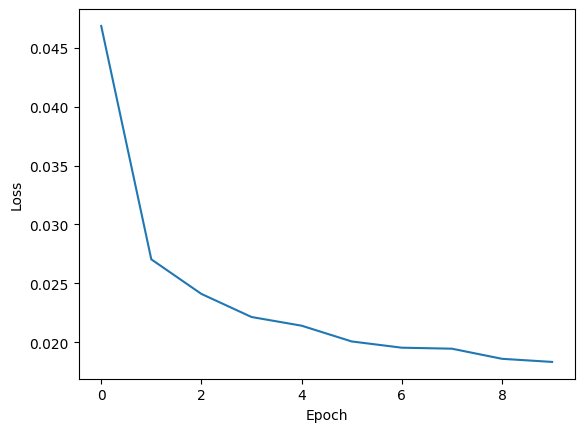

100%|██████████| 1000/1000 [01:25<00:00, 11.63it/s]


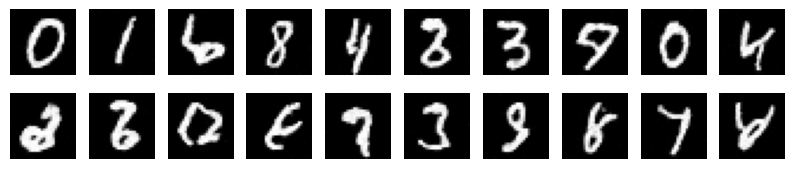

In [2]:
# The following code is from https://github.com/oreilly-japan/deep-learning-from-scratch-5 under MIT license.
import math
import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.optim import Adam
import torch.nn.functional as F
from torch import nn
from tqdm import tqdm


img_size = 28
batch_size = 128
num_timesteps = 1000
epochs = 10
lr = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'


def show_images(images, rows=2, cols=10):
    fig = plt.figure(figsize=(cols, rows))
    i = 0
    for r in range(rows):
        for c in range(cols):
            fig.add_subplot(rows, cols, i + 1)
            plt.imshow(images[i], cmap='gray')
            plt.axis('off')
            i += 1
    plt.show()

def _pos_encoding(time_idx, output_dim, device='cpu'):
    t, D = time_idx, output_dim
    v = torch.zeros(D, device=device)

    i = torch.arange(0, D, device=device)
    div_term = torch.exp(i / D * math.log(10000))

    v[0::2] = torch.sin(t / div_term[0::2])
    v[1::2] = torch.cos(t / div_term[1::2])
    return v

def pos_encoding(timesteps, output_dim, device='cpu'):
    batch_size = len(timesteps)
    device = timesteps.device
    v = torch.zeros(batch_size, output_dim, device=device)
    for i in range(batch_size):
        v[i] = _pos_encoding(timesteps[i], output_dim, device)
    return v

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_embed_dim):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )
        self.mlp = nn.Sequential(
            nn.Linear(time_embed_dim, in_ch),
            nn.ReLU(),
            nn.Linear(in_ch, in_ch)
        )

    def forward(self, x, v):
        N, C, _, _ = x.shape
        v = self.mlp(v)
        v = v.view(N, C, 1, 1)
        y = self.convs(x + v)
        return y

class UNet(nn.Module):
    def __init__(self, in_ch=1, time_embed_dim=100):
        super().__init__()
        self.time_embed_dim = time_embed_dim

        self.down1 = ConvBlock(in_ch, 64, time_embed_dim)
        self.down2 = ConvBlock(64, 128, time_embed_dim)
        self.bot1 = ConvBlock(128, 256, time_embed_dim)
        self.up2 = ConvBlock(128 + 256, 128, time_embed_dim)
        self.up1 = ConvBlock(128 + 64, 64, time_embed_dim)
        self.out = nn.Conv2d(64, in_ch, 1)

        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear')

    def forward(self, x, timesteps):
        v = pos_encoding(timesteps, self.time_embed_dim, x.device)

        x1 = self.down1(x, v)
        x = self.maxpool(x1)
        x2 = self.down2(x, v)
        x = self.maxpool(x2)

        x = self.bot1(x, v)

        x = self.upsample(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up2(x, v)
        x = self.upsample(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up1(x, v)
        x = self.out(x)
        return x


class Diffuser:
    def __init__(self, num_timesteps=1000, beta_start=0.0001, beta_end=0.02, device='cpu'):
        self.num_timesteps = num_timesteps
        self.device = device
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

    def add_noise(self, x_0, t):
        T = self.num_timesteps
        assert (t >= 1).all() and (t <= T).all()

        t_idx = t - 1  # alpha_bars[0] is for t=1
        alpha_bar = self.alpha_bars[t_idx]  # (N,)
        N = alpha_bar.size(0)
        alpha_bar = alpha_bar.view(N, 1, 1, 1)  # (N, 1, 1, 1)

        noise = torch.randn_like(x_0, device=self.device)
        x_t = torch.sqrt(alpha_bar) * x_0 + torch.sqrt(1 - alpha_bar) * noise
        return x_t, noise

    def denoise(self, model, x, t):
        T = self.num_timesteps
        assert (t >= 1).all() and (t <= T).all()

        t_idx = t - 1  # alphas[0] is for t=1
        alpha = self.alphas[t_idx]
        alpha_bar = self.alpha_bars[t_idx]
        alpha_bar_prev = self.alpha_bars[t_idx-1]

        N = alpha.size(0)
        alpha = alpha.view(N, 1, 1, 1)
        alpha_bar = alpha_bar.view(N, 1, 1, 1)
        alpha_bar_prev = alpha_bar_prev.view(N, 1, 1, 1)

        model.eval()
        with torch.no_grad():
            eps = model(x, t)
        model.train()

        noise = torch.randn_like(x, device=self.device)
        noise[t == 1] = 0  # no noise at t=1

        mu = (x - ((1-alpha) / torch.sqrt(1-alpha_bar)) * eps) / torch.sqrt(alpha)
        std = torch.sqrt((1-alpha) * (1-alpha_bar_prev) / (1-alpha_bar))
        return mu + noise * std

    def reverse_to_img(self, x):
        x = x * 255
        x = x.clamp(0, 255)
        x = x.to(torch.uint8)
        x = x.cpu()
        to_pil = transforms.ToPILImage()
        return to_pil(x)

    def sample(self, model, x_shape=(20, 1, 28, 28)):
        batch_size = x_shape[0]
        x = torch.randn(x_shape, device=self.device)

        for i in tqdm(range(self.num_timesteps, 0, -1)):
            t = torch.tensor([i] * batch_size, device=self.device, dtype=torch.long)
            x = self.denoise(model, x, t)

        images = [self.reverse_to_img(x[i]) for i in range(batch_size)]
        return images


preprocess = transforms.ToTensor()
dataset = torchvision.datasets.MNIST(root='./data', download=True, transform=preprocess)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

diffuser = Diffuser(num_timesteps, device=device)
model = UNet()
model.to(device)
optimizer = Adam(model.parameters(), lr=lr)

losses = []
for epoch in range(epochs):
    loss_sum = 0.0
    cnt = 0

    # generate samples every epoch ===================
    # images = diffuser.sample(model)
    # show_images(images)
    # ================================================

    for images, labels in tqdm(dataloader):
        optimizer.zero_grad()
        x = images.to(device)
        t = torch.randint(1, num_timesteps+1, (len(x),), device=device)

        x_noisy, noise = diffuser.add_noise(x, t)
        noise_pred = model(x_noisy, t)
        loss = F.mse_loss(noise, noise_pred)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        cnt += 1

    loss_avg = loss_sum / cnt
    losses.append(loss_avg)
    print(f'Epoch {epoch} | Loss: {loss_avg}')

# plot losses
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# generate samples
images = diffuser.sample(model)
show_images(images)